### **Human Ovary Atlas - Ambient RNA reduction via CellBender** ###
**Written by:** Josef Byrne
 
**Purpose:** Remove ambient RNA/background contamination from Human Ovary Atlas snucRNA-seq data using CellBender.

In [1]:
# Imports & Settings
# Note: cellbender 0.3.2 was run in Python 3.7.12
import os
from cellbender.remove_background.downstream import load_anndata_from_input_and_output
import matplotlib.pyplot as plt

import scanpy as sc
import numpy as np
import pandas as pd

import sys
import importlib_metadata

In [ ]:
### Define directories ###
nostromo_datadir="/path/to/project_directory"
python_analyses_dir = f"{nostromo_datadir}/python_analyses"
cellbender_adata_dir = f"{python_analyses_dir}/adata_objs/cellbender_intermeds"

cellbender_output_path = f"{nostromo_datadir}/soup_corrected_data"

#### Run CellBender ####

In [ ]:
# CellBender was run on raw Cell Ranger feature-barcode matrices for each sample.
# Output files were written as per-sample background-corrected .h5 matrices.

# Loop over plexes and samples and write data matrices for each sample to file
for plex_num in range(1, 5):
    batch_path = f"{nostromo_datadir}/cellranger_results/plex{plex_num}/outs/per_sample_outs"
    for sample_dir in os.listdir(batch_path):
        sample_dir_full = os.path.join(batch_path, sample_dir)
        sample_raw_h5path = os.path.join(sample_dir_full, "count/sample_raw_feature_bc_matrix.h5")
        os.mkdir(f"{cellbender_output_path}/plex{plex_num}/{sample_dir}")
        corrected_outs_path = f"{cellbender_output_path}/plex{plex_num}/{sample_dir}/{sample_dir}_cellbender.h5"
        print(corrected_outs_path)
        !cellbender remove-background \
            --cuda \
            --input {sample_raw_h5path} \
            --output {corrected_outs_path}

#### Import and align filtered matrices ####

In [ ]:
### Import original filtered data and cellbender corrected data ###

# Initiate an adata list to store objects
adata_list = []
adata_list_cb = []

# Loop over plexes and samples and write data matrices for each sample to file
for plex_num in range(1, 5):
    batch_path = f"{nostromo_datadir}/cellranger_results/plex{plex_num}/outs/per_sample_outs"
    for sample_dir in os.listdir(batch_path):
        sample_dir_full = os.path.join(batch_path, sample_dir)
        sample_h5path = os.path.join(sample_dir_full, "count/sample_filtered_feature_bc_matrix.h5")

        # Load 10x FILTERED DATA matrix data (to be used for filtering cellbender corrected data for deprecated probes, multiplets, etc.)
        adata = sc.read_10x_h5(sample_h5path)

        # Add sample metadata
        adata.obs['sample_ID'] = sample_dir
        adata.obs['SenNet_ID'] = sample_dir[:7]
        adata.obs['plex'] = plex_num

        # Store raw counts in layer
        adata.layers['raw_counts'] = adata.X.copy()

        # Add the AnnData object to the dictionary
        adata_list.append(adata)


        # Load CELLBENDER CORRECTED data, 10X UNFILTERED DATA, and add metadata of interest
        sample_cb_h5path = os.path.join(cellbender_output_path, f"plex{plex_num}/{sample_dir}/{sample_dir}_cellbender.h5")
        adata_cb = sc.read_10x_h5(sample_cb_h5path)
        unfiltered_sample_h5path = os.path.join(sample_dir_full, "count/sample_raw_feature_bc_matrix.h5")

        # This imports and compares the raw, uncorrected counts with the cellbender corrected counts and generates metadata for the cellbender results
        adata_withmetadata = load_anndata_from_input_and_output(
            input_file=unfiltered_sample_h5path,
            output_file=sample_cb_h5path,
            input_layer_key='raw')

        # Subset adata to only include observations in adata_withmetadata
        adata_cb = adata_cb[adata_withmetadata.obs_names]

        # Ensure obs_names match before copying metadata
        if not adata_cb.obs_names.equals(adata_withmetadata.obs_names):
            # Find and print the first mismatched observation names
            mismatched_obs_adata = next(iter(set(adata_cb.obs_names) - set(adata_withmetadata.obs_names)), None)
            mismatched_obs_withmetadata = next(iter(set(adata_withmetadata.obs_names) - set(adata_cb.obs_names)), None)
            print(f"First mismatched observation name in adata: {mismatched_obs_adata}")
            print(f"First mismatched observation name in adata_withmetadata: {mismatched_obs_withmetadata}")
            raise ValueError("Observation names do not match between adata and adata_withmetadata.")

        # Copy metadata of interest to adata_cb
        adata_cb.obs['background_fraction'] = adata_withmetadata.obs['background_fraction']
        adata_cb.obs['cell_probability'] = adata_withmetadata.obs['cell_probability']
        adata_cb.var['ambient_expression'] = adata_withmetadata.var['ambient_expression'].astype(float)
        adata_cb.var['n_raw'] = adata_withmetadata.var['n_raw'].astype(float)
        adata_cb.var['n_cellbender'] = adata_withmetadata.var['n_cellbender'].astype(float)

        # Add sample metadata to cellbender corrected data
        adata_cb.obs['sample_ID'] = sample_dir
        adata_cb.obs['SenNet_ID'] = sample_dir[:7]
        adata_cb.obs['plex'] = plex_num

        # Store raw counts in layer for cellbender corrected data
        adata_cb.layers['raw_counts'] = adata_cb.X.copy()

        # Add the AnnData object to the dictionary for cellbender corrected data
        adata_list_cb.append(adata_cb)


In [4]:
adata_withmetadata

AnnData object with n_obs × n_vars = 22840 × 39226
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_raw', 'n_cellbender'
    var: 'ambient_expression', 'feature_type', 'genome', 'gene_id', 'cellbender_analyzed', 'n_raw', 'n_cellbender'
    uns: 'cell_size_lognormal_std', 'empty_droplet_size_lognormal_loc', 'empty_droplet_size_lognormal_scale', 'swapping_fraction_dist_params', 'estimator', 'features_analyzed_inds', 'fraction_data_used_for_testing', 'learning_curve_learning_rate_epoch', 'learning_curve_learning_rate_value', 'learning_curve_test_elbo', 'learning_curve_test_epoch', 'learning_curve_train_elbo', 'learning_curve_train_epoch', 'target_false_positive_rate'
    obsm: 'cellbender_embedding'
    layers: 'raw', 'cellbender'

In [8]:
adata_list[1]

AnnData object with n_obs × n_vars = 6853 × 18099
    obs: 'sample_ID', 'SenNet_ID', 'plex'
    var: 'gene_ids', 'feature_types', 'genome'
    layers: 'raw_counts'

In [13]:
adata_list_cb[1]

AnnData object with n_obs × n_vars = 21980 × 39226
    obs: 'background_fraction', 'cell_probability', 'sample_ID', 'SenNet_ID', 'plex'
    var: 'gene_ids', 'feature_types', 'genome', 'ambient_expression', 'n_raw', 'n_cellbender'
    layers: 'raw_counts'

In [ ]:
# Some observations are missing from the CellBender-corrected data, likely due to background/low-quality droplets
# removed during CellBender import/filtering. This checks how many observations are missing from the
# CellBender-corrected data that are present in the original filtered 10x count data.
for index_num in range(len(adata_list)):
    adata_obs_names = set(adata_list[index_num].obs_names)
    adata_cb_obs_names = set(adata_list_cb[index_num].obs_names)
    diff_length = len(adata_obs_names - adata_cb_obs_names)
    print(f"Index {index_num}: Number of mismatched observation names {adata_list[index_num].obs['SenNet_ID'][0]}: {diff_length}")

Index 0: Number of mismatched observation names SN_0076: 0
Index 1: Number of mismatched observation names SN_0076: 0
Index 2: Number of mismatched observation names SN_0079: 0
Index 3: Number of mismatched observation names SN_0079: 0
Index 4: Number of mismatched observation names SN_0080: 0
Index 5: Number of mismatched observation names SN_0082: 0
Index 6: Number of mismatched observation names SN_0083: 0
Index 7: Number of mismatched observation names SN_0085: 0
Index 8: Number of mismatched observation names SN_0086: 0
Index 9: Number of mismatched observation names SN_0087: 0
Index 10: Number of mismatched observation names SN_0088: 0
Index 11: Number of mismatched observation names SN_0092: 0
Index 12: Number of mismatched observation names SN_0093: 0
Index 13: Number of mismatched observation names SN_0094: 0
Index 14: Number of mismatched observation names SN_0095: 0
Index 15: Number of mismatched observation names SN_0106: 0
Index 16: Number of mismatched observation names S

In [16]:
# Subset cellbender corrected data to only include obs and vars in filtered 10x count data
for i, adata_cb in enumerate(adata_list_cb):
    adata = adata_list[i]
    adata.var_names_make_unique()
    adata_cb.var_names_make_unique()
    # Retain obs that are in both adata and adata_cb
    common_obs_names = adata_cb.obs_names.intersection(adata.obs_names)
    adata_cb = adata_cb[:, adata.var_names]
    adata_cb = adata_cb[common_obs_names, :]
    adata_list_cb[i] = adata_cb

In [17]:
for i, (adata, adata_cb) in enumerate(zip(adata_list, adata_list_cb)):
    print(f"Index {i}: adata has {adata.n_obs} observations, adata_cb has {adata_cb.n_obs} observations")

Index 0: adata has 1201 observations, adata_cb has 1201 observations
Index 1: adata has 6853 observations, adata_cb has 6853 observations
Index 2: adata has 8573 observations, adata_cb has 8573 observations
Index 3: adata has 8986 observations, adata_cb has 8986 observations
Index 4: adata has 9270 observations, adata_cb has 9270 observations
Index 5: adata has 6917 observations, adata_cb has 6917 observations
Index 6: adata has 6352 observations, adata_cb has 6352 observations
Index 7: adata has 3849 observations, adata_cb has 3849 observations
Index 8: adata has 7307 observations, adata_cb has 7307 observations
Index 9: adata has 4191 observations, adata_cb has 4191 observations
Index 10: adata has 8128 observations, adata_cb has 8128 observations
Index 11: adata has 7020 observations, adata_cb has 7020 observations
Index 12: adata has 5631 observations, adata_cb has 5631 observations
Index 13: adata has 11677 observations, adata_cb has 11677 observations
Index 14: adata has 8791 obs

In [18]:
adata_list_cb[1]

View of AnnData object with n_obs × n_vars = 6853 × 18099
    obs: 'background_fraction', 'cell_probability', 'sample_ID', 'SenNet_ID', 'plex'
    var: 'gene_ids', 'feature_types', 'genome', 'ambient_expression', 'n_raw', 'n_cellbender'
    layers: 'raw_counts'

#### CellBender QC checks ####

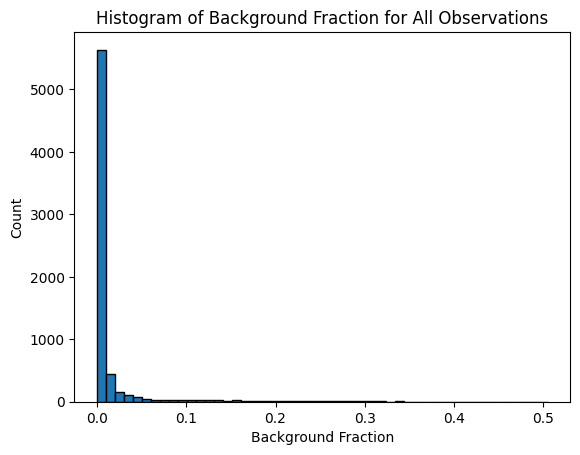

In [21]:
# Extract background_fraction for all observations
background_fraction = adata_list_cb[1].obs['background_fraction']

# Create histogram
plt.hist(background_fraction, bins=50, edgecolor='black')
plt.xlabel('Background Fraction')
plt.ylabel('Count')
plt.title('Histogram of Background Fraction for All Observations')
plt.show()

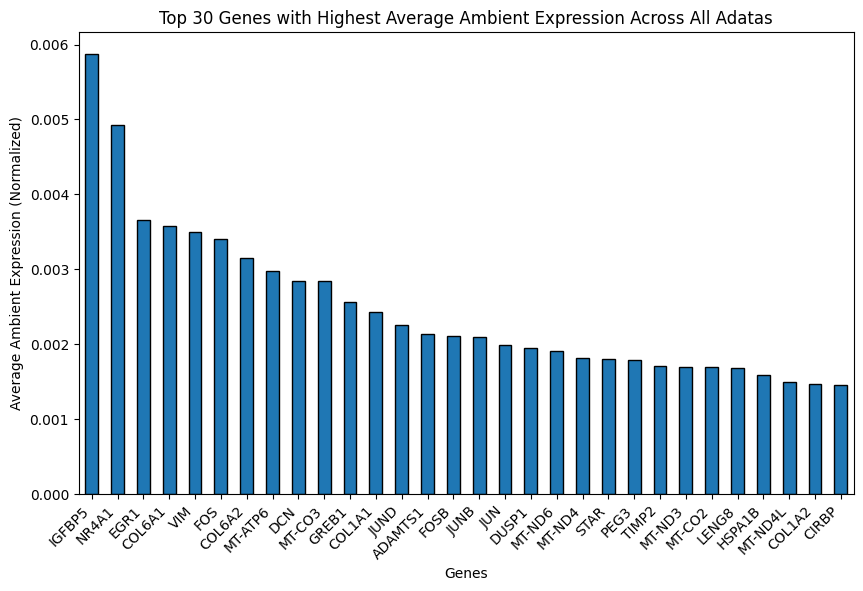

Top 30 Genes with Highest Average Ambient Expression:
['IGFBP5', 'NR4A1', 'EGR1', 'COL6A1', 'VIM', 'FOS', 'COL6A2', 'MT-ATP6', 'DCN', 'MT-CO3', 'GREB1', 'COL1A1', 'JUND', 'ADAMTS1', 'FOSB', 'JUNB', 'JUN', 'DUSP1', 'MT-ND6', 'MT-ND4', 'STAR', 'PEG3', 'TIMP2', 'MT-ND3', 'MT-CO2', 'LENG8', 'HSPA1B', 'MT-ND4L', 'COL1A2', 'CIRBP']


In [22]:
# Identify genes with highest average ambient expression across all samples (different from top genes removed for soup correction)

# Extract the ambient expression for all variables (genes) across all adatas in the list
ambient_expression_all = pd.concat([adata.var['ambient_expression'] for adata in adata_list_cb])

# Remove duplicates and take the average ambient expression across all samples
ambient_expression_avg = ambient_expression_all.groupby(ambient_expression_all.index).mean()

# Get the top 30 genes with the highest average ambient expression
top_30_genes_avg = ambient_expression_avg.nlargest(30)

# Plot the top 30 genes with the highest average ambient expression
plt.figure(figsize=(10, 6))
top_30_genes_avg.plot(kind='bar', edgecolor='black')
plt.xlabel('Genes')
plt.ylabel('Average Ambient Expression (Normalized)')
plt.title('Top 30 Genes with Highest Average Ambient Expression Across All Adatas')
plt.xticks(rotation=45, ha='right')
plt.show()

# Print the top 30 genes with the highest average ambient expression as a list
print("Top 30 Genes with Highest Average Ambient Expression:")
print(top_30_genes_avg.index.tolist())


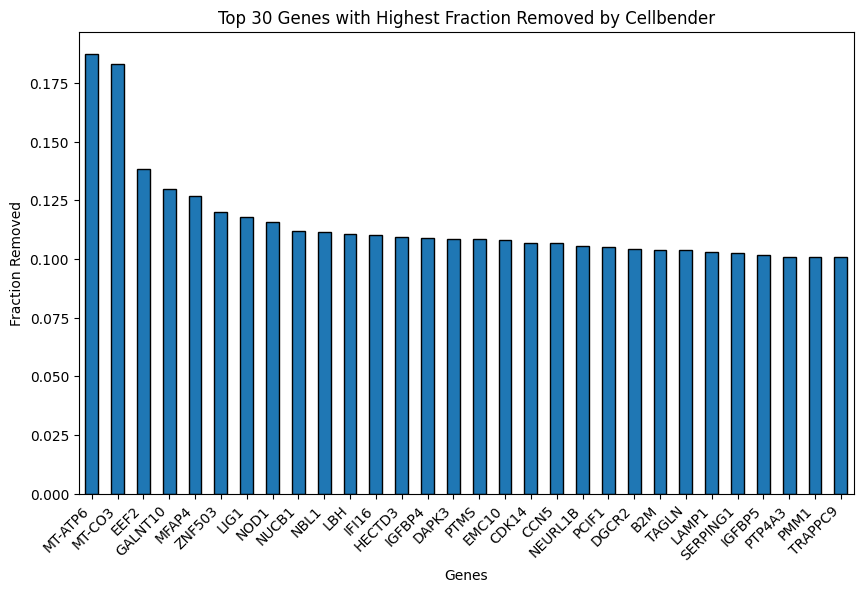

Top 30 Genes with Highest Fraction Removed:
['MT-ATP6', 'MT-CO3', 'EEF2', 'GALNT10', 'MFAP4', 'ZNF503', 'LIG1', 'NOD1', 'NUCB1', 'NBL1', 'LBH', 'IFI16', 'HECTD3', 'IGFBP4', 'DAPK3', 'PTMS', 'EMC10', 'CDK14', 'CCN5', 'NEURL1B', 'PCIF1', 'DGCR2', 'B2M', 'TAGLN', 'LAMP1', 'SERPING1', 'IGFBP5', 'PTP4A3', 'PMM1', 'TRAPPC9']


In [9]:
# Determine top genes that were removed by cellbender
input_adata = adata_list_cb[0].copy()

# Make gene mask to only include genes with >= 90th percentile of counts
percentile_90 = np.percentile(input_adata.var['n_raw'], 90)
filtered_genes = input_adata.var['n_raw'] >= percentile_90

# Create a boolean mask for cells with cell_probability > 0.5
cellbender_cell_barcodes = input_adata.obs['cell_probability'] > 0.5

# Use this mask to filter the observations and genes
adata_filtered = input_adata[cellbender_cell_barcodes, filtered_genes].copy()

# Compute the fraction removed by cellbender
adata_filtered.var['fraction_removed_from_cells'] = (adata_filtered.var['n_raw'].values - adata_filtered.var['n_cellbender'].values) / adata_filtered.var['n_raw'].values

# Get the top 30 genes with the highest fraction removed
top_30_genes_fraction_removed = adata_filtered.var['fraction_removed_from_cells'].nlargest(30)

# Plot the top 30 genes with the highest fraction removed
plt.figure(figsize=(10, 6))
top_30_genes_fraction_removed.plot(kind='bar', edgecolor='black')
plt.xlabel('Genes')
plt.ylabel('Fraction Removed')
plt.title('Top 30 Genes with Highest Fraction Removed by Cellbender')
plt.xticks(rotation=45, ha='right')
plt.show();

# Print the top 30 genes with the highest fraction removed as a list
print("Top 30 Genes with Highest Fraction Removed:")
print(top_30_genes_fraction_removed.index.tolist())

#### Save files & session info ####

In [ ]:
# Save each adata object in adata_list_cb with the specified naming convention
for adata in adata_list_cb:
    sennet_id = adata.obs['sample_ID'][0]
    plex_num = adata.obs['plex'][0]
    filename = f"{sennet_id}_p{plex_num}_cellbender.h5ad"
    filepath = os.path.join(cellbender_adata_dir, filename)
    adata.write(filepath)
    print(f"Saved {filename} to {cellbender_adata_dir}")

In [24]:
# List of imported modules & versions of packages used by scanpy
sc.settings.verbosity = 3
sc.logging.print_header()

# Print the version of each python module
for module_name in sys.modules:
    try:
        version = importlib_metadata.version(module_name)
        print(f"{module_name} version: {version}")
    except importlib_metadata.PackageNotFoundError:
        # Skip modules that don't have a version available
        continue
    except Exception as e:
        # Handle any other exceptions that might occur
        print(f"Error retrieving version for {module_name}: {e}")

scanpy==1.9.3 anndata==0.8.0 numpy==1.21.6 scipy==1.7.3 pandas==1.3.5 scikit-learn==1.0.2 statsmodels==0.13.5 pynndescent==0.5.13
ipykernel version: 6.16.2
jupyter_client version: 7.4.9
traitlets version: 5.9.0
typing_extensions version: 4.7.1
tornado version: 6.2
six version: 1.16.0
jupyter_core version: 4.12.0
entrypoints version: 0.4
IPython version: 7.34.0
pygments version: 2.17.2
pexpect version: 4.9.0
ptyprocess version: 0.7.0
decorator version: 5.1.1
pickleshare version: 0.7.5
backcall version: 0.2.0
prompt_toolkit version: 3.0.48
wcwidth version: 0.2.13
jedi version: 0.19.1
parso version: 0.8.4
psutil version: 6.1.0
debugpy version: 1.7.0
packaging version: 24.0
ipywidgets version: 8.1.5
comm version: 0.1.4
cellbender version: 0.3.2
tables version: 3.7.0
numpy version: 1.21.6
numexpr version: 2.8.6
anndata version: 0.8.0
importlib_metadata version: 6.7.0
zipp version: 3.15.0
h5py version: 3.8.0
natsort version: 8.4.0
pandas version: 1.3.5
pytz version: 2024.2
scipy version: 1.7